# Image Classification using Neural Network and Convolutional Neural Network Approaches

This notebook implements two deep learning approaches for image classification on TinyImageNet100:

1. **Fully-Connected Neural Network (MLP)**: classifies images from flattened pixel inputs
2. **Convolutional Neural Network (CNN)**: learns hierarchical spatial features directly from images

Both are evaluated on the same 15-class subset and compared against the Assignment 1 baseline (SIFT + Fisher Vectors + SVM), which is reproduced here for a verifiable comparison.

## 1. Setup and Imports

In [1]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

random_state = 40466218
random.seed(random_state)
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_state)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.6.0+cu124


### Visualisation Style

A consistent style is applied throughout so figures can be used directly in the report.

In [2]:
plt.rcParams.update({
    'figure.figsize': (10,6),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_style('whitegrid')

CB = sns.color_palette('colorblind')
C_A1, C_NN, C_CNN = CB[3], CB[0], CB[2]   # coral, blue, green

os.makedirs('figures', exist_ok=True)

def save_fig(fig, name):
    """Save a figure to the figures folder."""
    fig.savefig(f'figures/{name}.png', bbox_inches='tight')

## 2. Dataset Preparation

We reuse the identical 15 classes and 80/20 train/test split from Assignment 1. Images are sorted alphabetically within each class: the first 350 are for training, the next 50 for validation the last 100 for test.

In [3]:
# Select the 15 classes, randomly sampled with my student seed

ROOT_PATH = Path("TinyImageNet100_2026")

def load_class_names(path):
    "Read a tab-separated mapping file and return a dict with class IDs and names."
    m = {}
    with open(path) as f:
        for line in f:
            if '\t' in line:
                k, v = line.strip().split('\t', 1)
                m[k] = v
    return m

full_class_map = load_class_names(ROOT_PATH / "class_name.txt")

all_classes = sorted(
    entry.name
    for entry in ROOT_PATH.iterdir()
    if entry.is_dir() and entry.name.startswith("n")
)

selected_classes = sorted(random.sample(all_classes, k=15))
NUM_CLASSES = len(selected_classes)

label_map = {cls: full_class_map.get(cls, cls) for cls in selected_classes}
class_to_idx = {cls: idx for idx, cls in enumerate(selected_classes)}
idx_to_class = dict(enumerate(selected_classes))
short_names = [label_map[cls].split(",", 1)[0] for cls in selected_classes]

print(f"Selected {NUM_CLASSES} classes:")
print("\n".join(f"  {cls}: {label_map[cls]}" for cls in selected_classes))

Selected 15 classes:
  n03637318: lampshade, lamp shade
  n03733131: maypole
  n03814639: neck brace
  n03837869: obelisk
  n03977966: police van, police wagon, paddy wagon, patrol wagon, wagon, black Maria
  n04099969: rocking chair, rocker
  n04133789: sandal
  n04328186: stopwatch, stop watch
  n04532106: vestment
  n04596742: wok
  n07615774: ice lolly, lolly, lollipop, popsicle
  n07715103: cauliflower
  n07768694: pomegranate
  n09332890: lakeside, lakeshore
  n09428293: seashore, coast, seacoast, sea-coast


In [4]:
# Split the images into train, val and test files with images and corresponding labels, ordered alphabetically

train_files, val_files, test_files = [], [], []

for cls in selected_classes:
    class_dir = ROOT_PATH / cls / 'images'
    images = sorted([str(p) for p in class_dir.glob('*.JPEG')])
    label  = class_to_idx[cls]
    for img in images[:350]:   train_files.append((img, label))
    for img in images[350:400]: val_files.append((img, label))
    for img in images[400:500]: test_files.append((img, label))

print(f"Training:   {len(train_files)}")
print(f"Validation: {len(val_files)}")
print(f"Test:       {len(test_files)}")

Training:   5250
Validation: 750
Test:       1500


In [5]:
# Calculate mean and standard deviation per colour channel for the images to use in data normalisation

pixel_sum    = np.zeros(3)
pixel_sq_sum = np.zeros(3)
n_pixels     = 0

for img_path, _ in train_files:
    img = np.array(Image.open(img_path).convert('RGB'), dtype=np.float64) / 255.0
    pixel_sum    += img.sum(axis=(0, 1))
    pixel_sq_sum += (img ** 2).sum(axis=(0, 1))
    n_pixels     += img.shape[0] * img.shape[1]

dataset_mean = pixel_sum    / n_pixels
dataset_std  = np.sqrt(pixel_sq_sum / n_pixels - dataset_mean ** 2)
print(f"Mean: {dataset_mean}  Std: {dataset_std}")

Mean: [0.4920873  0.45517359 0.41562857]  Std: [0.28405162 0.28110739 0.296945  ]


In [6]:
# Load the images as a PyTorch Dataset and apply two sets of transformations
# Convert the images into tensors for PyTorch to process, and normalise the data for all datasets
# For training data only, apply flipping, cropping, colour jitter and rotation as data augmentation
# Then create data loaders to split the data into mini-batches for faster training

class TinyImageNetSubset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        """Load one image-label pair by index."""
        path, label = self.file_list[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean.tolist(), std=dataset_std.tolist())
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean.tolist(), std=dataset_std.tolist())
])

BATCH_SIZE    = 64
train_dataset = TinyImageNetSubset(train_files, train_transform)
val_dataset   = TinyImageNetSubset(val_files,   eval_transform)
test_dataset  = TinyImageNetSubset(test_files,  eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=128,        shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=128,        shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 83 | Val: 6 | Test: 12


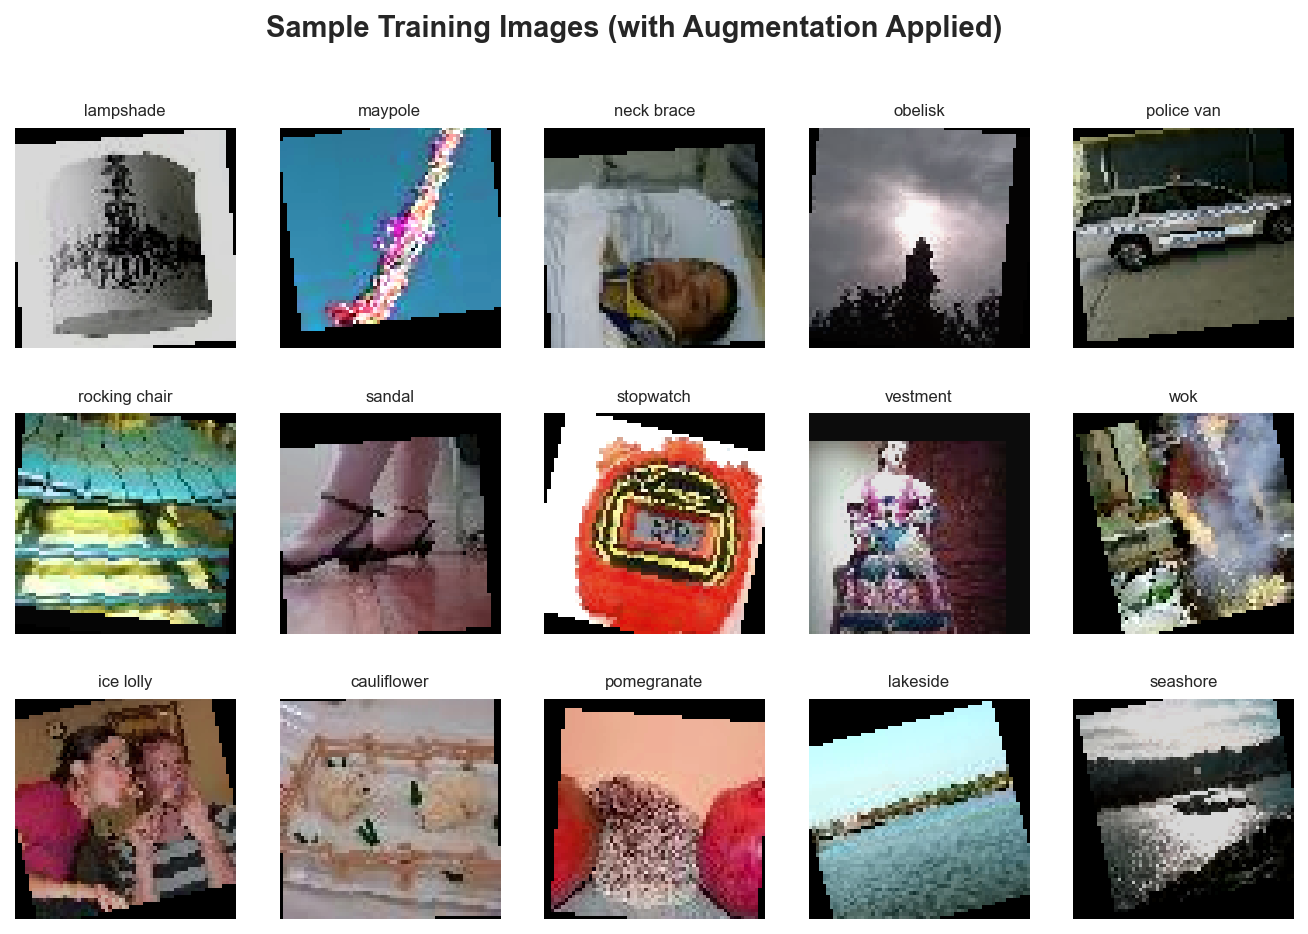

In [7]:
# Show some sample training images after cropping, rotation, etc.

fig, axes = plt.subplots(3, 5, figsize=(11, 7))
fig.suptitle("Sample Training Images (with Augmentation Applied)", fontweight='bold')

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i * (len(train_dataset) // 15)]
    img_d = img.clone()
    for c in range(3):
        img_d[c] = img_d[c] * dataset_std[c] + dataset_mean[c]
    ax.imshow(img_d.clamp(0, 1).permute(1, 2, 0).numpy())
    ax.set_title(short_names[label], fontsize=8)
    ax.axis('off')

save_fig(fig, 'sample_images')
plt.show()

## 3. Assignment 1 Baseline Reproduction

The SIFT + Fisher Vectors + LinearSVM pipeline from Assignment 1 is reproduced here to obtain verified per-class metrics on the same test split. This avoids hardcoding values and ensures a like-for-like comparison.

In [8]:
# Extract SIFT features and encode as Fisher Vectors

def extract_sift(image_paths):
    """SIFT with the optimised parameters from Assignment 1."""
    sift = cv2.SIFT_create(nOctaveLayers=5, contrastThreshold=0.001,
                           edgeThreshold=20, sigma=0.8)
    descs = []
    print("Extracting SIFT features...")
    t0 = time.time()
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        _, d = sift.detectAndCompute(img, None)
        descs.append(d.astype(np.float32) if d is not None else None)
    print(f"  Done in {time.time()-t0:.1f}s ({len(descs)} images)")
    return descs


class FisherVectorEncoder:
    """Fisher Vector encoder: identical to Assignment 1 implementation."""
    def __init__(self, k=128, pca_dim=64):
        """Set encoder dimensions and model components."""
        self.k, self.pca_dim = k, pca_dim
        self.gmm = GaussianMixture(n_components=k, covariance_type='diag',
                                   random_state=random_state)
        self.pca = PCA(n_components=pca_dim)

    def fit(self, stacked):
        """Fit PCA and GMM on stacked descriptors."""
        d = stacked.copy()
        d /= (d.sum(axis=1, keepdims=True) + 1e-7)
        d  = np.sqrt(d)
        print(f"  Fitting PCA (128 -> {self.pca_dim})...")
        self.pca.fit(d)
        print(f"  Training GMM (K={self.k})...")
        self.gmm.fit(self.pca.transform(d))

    def transform(self, descs):
        """Encode descriptors into Fisher vectors."""
        print("  Encoding Fisher Vectors...")
        w, mu, cov = self.gmm.weights_, self.gmm.means_, self.gmm.covariances_
        sig = np.sqrt(cov)
        iw  = (1.0 / np.sqrt(w)).reshape(-1, 1)
        fvs = []
        for d in descs:
            if d is None or len(d) == 0:
                fvs.append(np.zeros(2 * self.k * self.pca_dim))
                continue
            d = d.copy()
            d /= (d.sum(axis=1, keepdims=True) + 1e-7)
            d  = np.sqrt(d)
            x  = self.pca.transform(d)
            g  = self.gmm.predict_proba(x)
            xn = (x[:, None, :] - mu[None, :, :]) / sig[None, :, :]
            fv_mu  = (g[:, :, None] * xn).sum(0)        * iw
            fv_sig = (g[:, :, None] * (xn**2 - 1)).sum(0) * iw
            fv = np.hstack([fv_mu.flatten(), fv_sig.flatten()])
            fv /= x.shape[0]
            fv  = np.sign(fv) * np.sqrt(np.abs(fv))
            n   = np.linalg.norm(fv)
            if n > 0:
                fv /= n
            fvs.append(fv)
        return np.array(fvs)

def print_classification_summary(y_true, y_pred, class_names, title):
    """Print a consistent classification report heading and table."""
    print(f"\nClassification Report: {title}")
    print(classification_report(y_true, y_pred, target_names=class_names))

In [9]:
# Use full 400 train images per class (train + val combined, as we don't need val to tune hyperparams again)
a1_train_paths, a1_train_labels = zip(*(train_files + val_files))
a1_test_paths, a1_test_labels   = zip(*test_files)
a1_train_paths, a1_train_labels = list(a1_train_paths), list(a1_train_labels)
a1_test_labels = np.array(a1_test_labels)

train_des = extract_sift(a1_train_paths)
test_des  = extract_sift(a1_test_paths)

# Subsample for GMM fitting
all_des = np.vstack([d for d in train_des if d is not None])
if len(all_des) > 200000:
    idx     = np.random.choice(len(all_des), 200000, replace=False)
    all_des = all_des[idx]
print(f"  Descriptors for GMM: {all_des.shape}")

fv_enc     = FisherVectorEncoder(k=128, pca_dim=64)
fv_enc.fit(all_des)
X_train_fv = fv_enc.transform(train_des)
X_test_fv  = fv_enc.transform(test_des)

scaler_a1  = StandardScaler()
X_train_fv = scaler_a1.fit_transform(X_train_fv)
X_test_fv  = scaler_a1.transform(X_test_fv)

print("  Training LinearSVM (C=1e-5)...")
svm = LinearSVC(C=1e-5, random_state=random_state, max_iter=2000)
svm.fit(X_train_fv, a1_train_labels)

a1_preds    = svm.predict(X_test_fv)
a1_accuracy = accuracy_score(a1_test_labels, a1_preds)
print(f"\nA1 Baseline Test Accuracy: {a1_accuracy:.2%}")

Extracting SIFT features...
  Done in 17.5s (6000 images)
Extracting SIFT features...
  Done in 5.8s (1500 images)
  Descriptors for GMM: (200000, 128)
  Fitting PCA (128 -> 64)...
  Training GMM (K=128)...
  Encoding Fisher Vectors...
  Encoding Fisher Vectors...
  Training LinearSVM (C=1e-5)...

A1 Baseline Test Accuracy: 55.87%


In [10]:
# Present the results by class and overall

print_classification_summary(a1_test_labels, a1_preds, short_names, "A1 (SIFT + FV + SVM)")


Classification Report: A1 (SIFT + FV + SVM)
               precision    recall  f1-score   support

    lampshade       0.56      0.48      0.52       100
      maypole       0.49      0.77      0.60       100
   neck brace       0.48      0.31      0.38       100
      obelisk       0.62      0.70      0.66       100
   police van       0.62      0.88      0.72       100
rocking chair       0.59      0.50      0.54       100
       sandal       0.53      0.54      0.53       100
    stopwatch       0.68      0.73      0.71       100
     vestment       0.61      0.38      0.47       100
          wok       0.55      0.32      0.41       100
    ice lolly       0.42      0.29      0.34       100
  cauliflower       0.56      0.81      0.66       100
  pomegranate       0.60      0.71      0.65       100
     lakeside       0.49      0.25      0.33       100
     seashore       0.50      0.71      0.59       100

     accuracy                           0.56      1500
    macro avg     

## 4. Training Utilities

In [11]:
# Reusable training functions to be used for all subsequent neural networks:
# run one epoch (train/eval), store results over each loop, implement early stopping and get predictions

def run_epoch(model, loader, criterion, device, optimizer=None):
    """Run one epoch in train mode when optimizer is provided, otherwise eval mode."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    running_loss = correct = total = 0
    ctx = torch.enable_grad if is_train else torch.no_grad

    with ctx():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            out = model(inputs)
            loss = criterion(out, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, pred = out.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                epochs, patience, device):
    """Full training loop with early stopping. Returns history dict."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    best_state = None
    patience_counter = 0
    t0 = time.time()

    for epoch in range(epochs):
        tl, ta = run_epoch(model, train_loader, criterion, device, optimizer=optimizer)
        vl, va = run_epoch(model, val_loader, criterion, device, optimizer=None)
        lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        history['lr'].append(lr)

        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(vl)
        else:
            scheduler.step()

        if va > best_val_acc:
            best_val_acc = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {tl:.4f} Acc: {ta:.4f} | "
                  f"Val Loss: {vl:.4f} Acc: {va:.4f} | "
                  f"LR: {lr:.6f} | Time: {time.time()-t0:.0f}s")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    total_time = time.time() - t0
    print(f"  Done in {total_time:.1f}s | Best val acc: {best_val_acc:.2%}")
    model.load_state_dict(best_state)
    history['training_time'] = total_time
    history['best_val_acc'] = best_val_acc
    return history


def make_adam_plateau(model, lr=1e-3, weight_decay=1e-4,
                      scheduler_patience=5, scheduler_factor=0.5):
    """Create an Adam optimizer and ReduceLROnPlateau scheduler pair."""
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=scheduler_patience, factor=scheduler_factor
    )
    return optimizer, scheduler


def run_experiment(name, model, *, train_loader, val_loader, test_loader,
                   lr=1e-3, weight_decay=1e-4,
                   scheduler_patience=5, scheduler_factor=0.5,
                   criterion=None, epochs=100, patience=20, device=device):
    """Train and evaluate one experiment with explicit parameters."""
    criterion = nn.CrossEntropyLoss() if criterion is None else criterion
    optimizer, scheduler = make_adam_plateau(
        model,
        lr=lr,
        weight_decay=weight_decay,
        scheduler_patience=scheduler_patience,
        scheduler_factor=scheduler_factor,
    )

    print(f"\n{'='*55}\nTraining {name}\n{'='*55}")
    hist = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler,
        epochs=epochs, patience=patience, device=device
    )
    _, test_acc = run_epoch(model, test_loader, criterion, device, optimizer=None)
    hist['test_acc'] = test_acc
    print(f"  Test accuracy: {test_acc:.2%}")
    return hist


def get_predictions(model, loader, device):
    """Collect predicted and true labels from a loader."""
    model.eval()
    preds, labels_out = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            out = model(inputs.to(device))
            _, pred = out.max(1)
            preds.extend(pred.cpu().numpy())
            labels_out.extend(labels.numpy())
    return np.array(preds), np.array(labels_out)


def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [12]:
# Reusable plotting functions to display learning curves, comparisons, and confusion analyses

def select_best_result(results, metric='test_acc'):
    """Return the best config name and its history by metric."""
    best_name = max(results, key=lambda name: results[name][metric])
    return best_name, results[best_name]


def print_metric_table(title, header, rows):
    """Print a consistently formatted text table."""
    print(title)
    print(header)
    print("-" * len(header))
    for row in rows:
        print(row)


def format_results_table(title, results, columns):
    """Build and print a metric table from a results dict and simple column specs.

    columns: list of (label, key) pairs; use key='name' for row label.
    results: dict of {name: row_dict}
    """
    header = " | ".join(label for label, _ in columns)

    rows = []
    for name, row_data in results.items():
        row = []
        for _, key in columns:
            value = name if key == 'name' else row_data[key]
            row.append(str(value))
        rows.append(" | ".join(row))

    print_metric_table(title, header, rows)


def plot_training_overlay(histories, title):
    """Overlay validation curves for multiple models on one figure."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    colours = sns.color_palette('colorblind', n_colors=len(histories))

    for idx, (name, h) in enumerate(histories.items()):
        ep = range(1, len(h['train_loss']) + 1)
        c = colours[idx]
        ax1.plot(ep, h['train_loss'], color=c, alpha=0.35, lw=1.5)
        ax1.plot(ep, h['val_loss'], color=c, lw=2, label=name)
        ax2.plot(ep, h['train_acc'], color=c, alpha=0.35, lw=1.5)
        ax2.plot(ep, h['val_acc'], color=c, lw=2, label=name)

    for ax, ylabel, subtitle in [(ax1, 'Loss', 'Loss'), (ax2, 'Accuracy', 'Accuracy')]:
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{title}: {subtitle}  (solid = val, faded = train)')
        ax.legend()
    return fig


def plot_cm(y_true, y_pred, class_names, title, ax):
    """Confusion matrix with count annotations."""
    cm = confusion_matrix(y_true, y_pred)

    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = str(cm[i, j]) if cm[i, j] > 0 else ""

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, ax=ax, linewidths=0.4)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    return cm.diagonal() / cm.sum(axis=1)

## 5. Fully-Connected Neural Network (MLP)

Three configurations compare the effect of depth and width. All use Batch Normalisation + Dropout and are trained with identical optimiser settings for a fair comparison.

| Config | Layers | Rationale |
|--------|--------|-----------|
| **A (Shallow)** | 512 * 256 | Baseline: quick convergence test |
| **B (Deep)** | 1024 * 512 * 256 * 128 | More granular decision boundaries |
| **C (Wide)** | 2048 * 1024 | Increased capacity at same depth as A |

In [13]:
# Build a base neural network with a linear layer, batch normalisation, ReLU activation
# but with variable numbers of layers, hidden sizes/neurons and dropout rates
# Test configurations with 2-4 layers of different sizes with different rates of dropout

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, num_classes, dropout_rates):
        """Build an MLP from hidden-layer settings."""
        super().__init__()
        layers, input_features = [], input_dim
        for h, d in zip(hidden_sizes, dropout_rates):
            layers += [nn.Linear(input_features, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(d)]
            input_features = h
        layers.append(nn.Linear(input_features, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """Run a forward pass on image tensors."""
        return self.net(x.view(x.size(0), -1))

INPUT_DIM  = 3 * 64 * 64  # 12,288

nn_configs = {
    'A (Shallow)': {'hidden_sizes': [512, 256],           'dropout_rates': [0.3, 0.3]},
    'B (Deep)':    {'hidden_sizes': [1024, 512, 256, 128], 'dropout_rates': [0.4, 0.4, 0.3, 0.3]},
    'C (Wide)':    {'hidden_sizes': [2048, 1024],          'dropout_rates': [0.5, 0.4]},
}

for name, config in nn_configs.items():
    m = MLP(INPUT_DIM, config['hidden_sizes'], NUM_CLASSES, config['dropout_rates'])
    print(f"Config {name}: {config['hidden_sizes']} | Params: {count_params(m):,}")

Config A (Shallow): [512, 256] | Params: 6,428,687
Config B (Deep): [1024, 512, 256, 128] | Params: 13,278,735
Config C (Wide): [2048, 1024] | Params: 27,287,567


### 5.1 Training

All three configs use **Adam** (lr=1e-3, weight_decay=1e-4) with **ReduceLROnPlateau** (patience=5, factor=0.5) and early stopping (patience=20).

In [14]:
# Run the full training loop and store the results for all three model configurations

nn_results = {}
nn_models = {}

for name, cfg in nn_configs.items():
    model = MLP(INPUT_DIM, cfg['hidden_sizes'], NUM_CLASSES, cfg['dropout_rates']).to(device)
    hist = run_experiment(
        f"MLP {name}",
        model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
    )
    nn_results[name] = hist
    nn_models[name] = model


Training MLP A (Shallow)
  Epoch   1/100 | Train Loss: 2.4936 Acc: 0.1787 | Val Loss: 2.2624 Acc: 0.2893 | LR: 0.001000 | Time: 6s
  Epoch  10/100 | Train Loss: 2.1485 Acc: 0.2924 | Val Loss: 1.9338 Acc: 0.3800 | LR: 0.001000 | Time: 77s
  Epoch  20/100 | Train Loss: 2.0575 Acc: 0.3192 | Val Loss: 1.8947 Acc: 0.3960 | LR: 0.001000 | Time: 150s
  Epoch  30/100 | Train Loss: 2.0031 Acc: 0.3429 | Val Loss: 1.8576 Acc: 0.4133 | LR: 0.000500 | Time: 230s
  Epoch  40/100 | Train Loss: 1.9608 Acc: 0.3625 | Val Loss: 1.8182 Acc: 0.4360 | LR: 0.000500 | Time: 303s
  Epoch  50/100 | Train Loss: 1.8978 Acc: 0.3777 | Val Loss: 1.8036 Acc: 0.4347 | LR: 0.000250 | Time: 381s
  Epoch  60/100 | Train Loss: 1.8718 Acc: 0.3808 | Val Loss: 1.7848 Acc: 0.4360 | LR: 0.000250 | Time: 455s
  Epoch  70/100 | Train Loss: 1.8521 Acc: 0.3930 | Val Loss: 1.7585 Acc: 0.4373 | LR: 0.000125 | Time: 532s
  Early stopping at epoch 78
  Done in 596.6s | Best val acc: 45.87%
  Test accuracy: 42.93%

Training MLP B (Dee

### 5.2 Results

MLP Configuration Comparison
Config | Val Acc | Test Acc
---------------------------
A (Shallow) | 45.87% | 42.93%
B (Deep) | 43.33% | 40.13%
C (Wide) | 46.93% | 45.20%

Best: C (Wide)


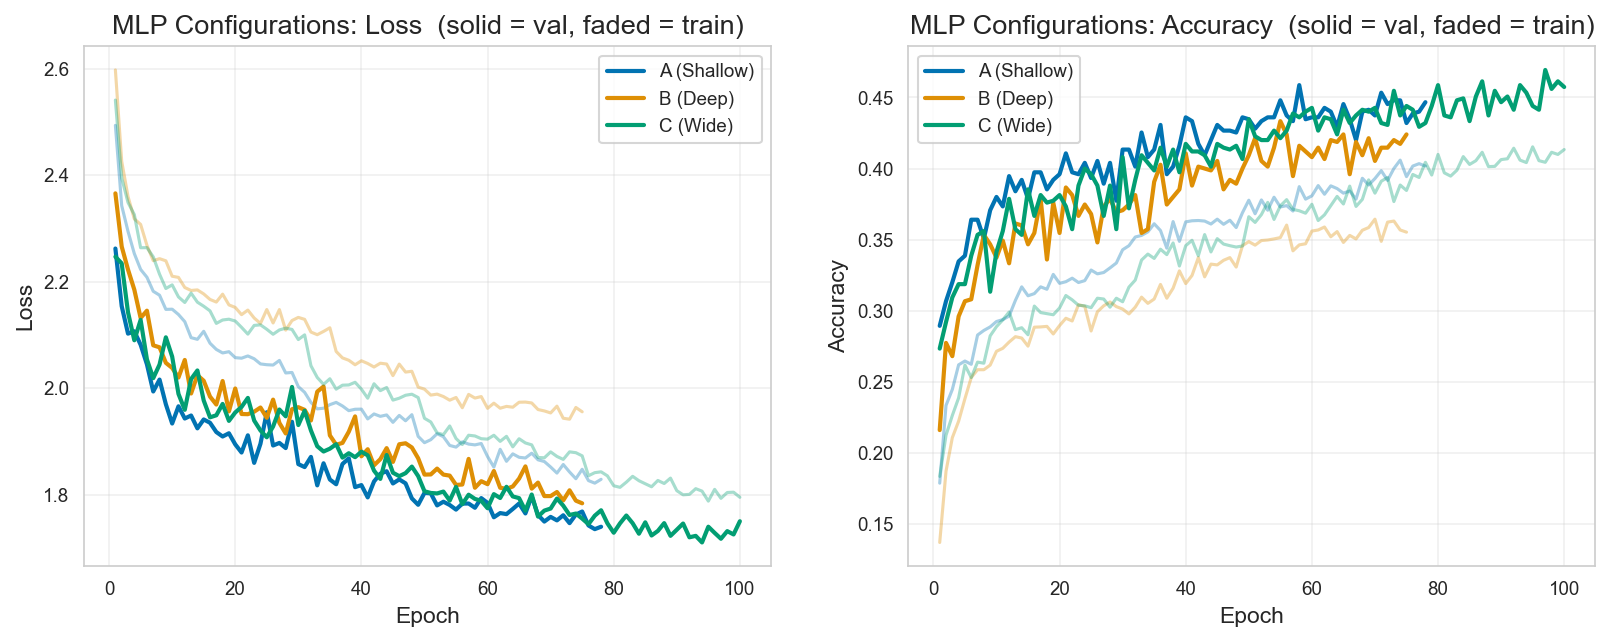

In [15]:
# Display the val and test accuracy for all three model configs and display the learning curves

nn_summary = {
    name: {
        'val_acc': f"{metrics['best_val_acc']:.2%}",
        'test_acc': f"{metrics['test_acc']:.2%}",
    }
    for name, metrics in nn_results.items()
}

format_results_table(
    "MLP Configuration Comparison",
    nn_summary,
    [
        ('Config', 'name'),
        ('Val Acc', 'val_acc'),
        ('Test Acc', 'test_acc'),
    ]
)

best_nn_name, _ = select_best_result(nn_results)
print(f"\nBest: {best_nn_name}")

fig = plot_training_overlay(nn_results, "MLP Configurations")
save_fig(fig, 'mlp_curves')
plt.show()

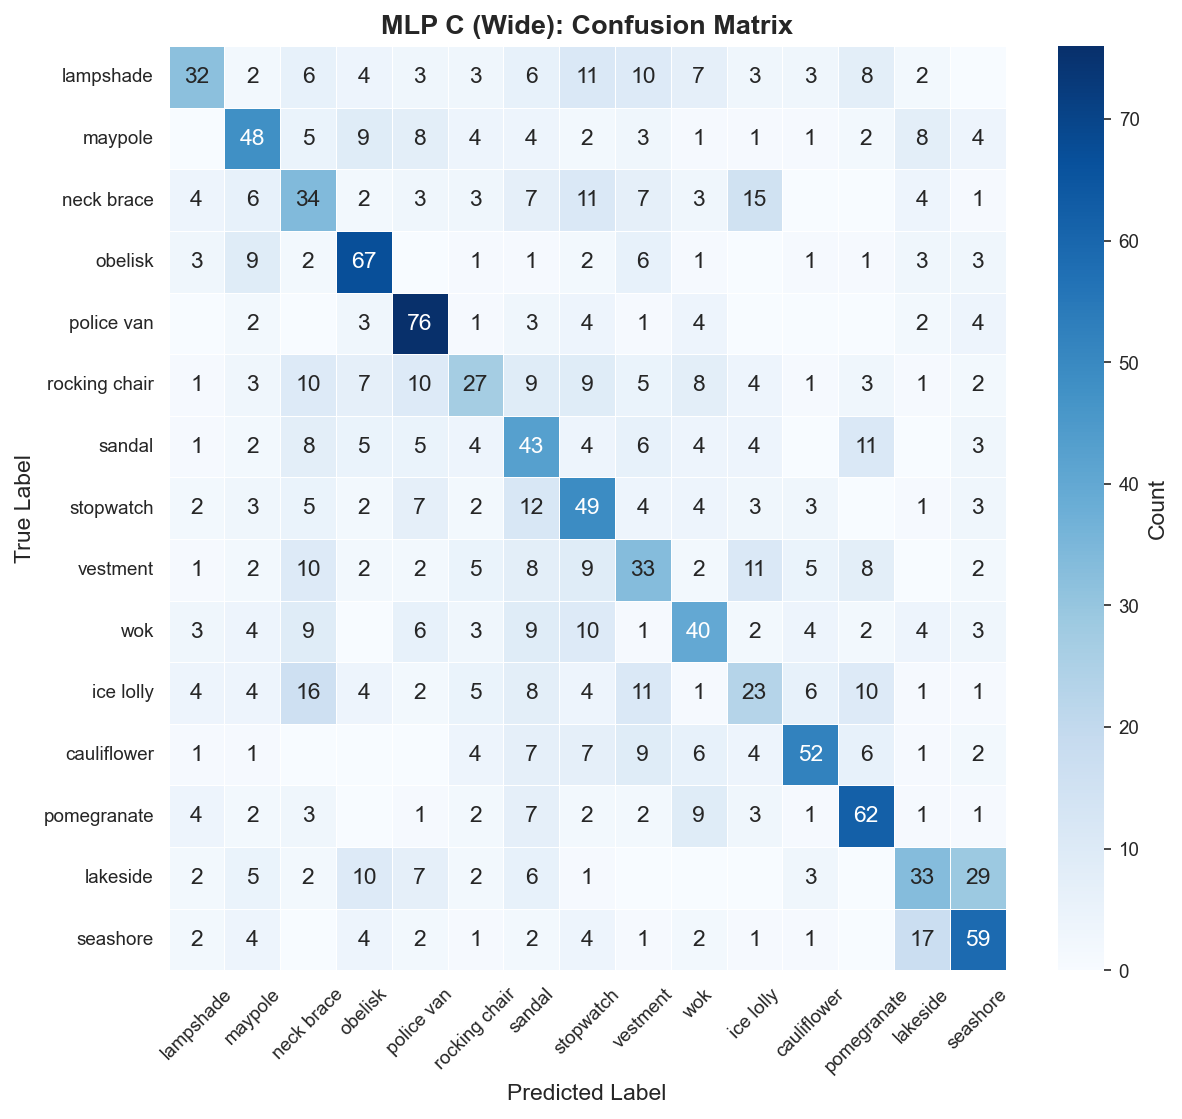


Classification Report: MLP C (Wide)
               precision    recall  f1-score   support

    lampshade       0.53      0.32      0.40       100
      maypole       0.49      0.48      0.49       100
   neck brace       0.31      0.34      0.32       100
      obelisk       0.56      0.67      0.61       100
   police van       0.58      0.76      0.66       100
rocking chair       0.40      0.27      0.32       100
       sandal       0.33      0.43      0.37       100
    stopwatch       0.38      0.49      0.43       100
     vestment       0.33      0.33      0.33       100
          wok       0.43      0.40      0.42       100
    ice lolly       0.31      0.23      0.26       100
  cauliflower       0.64      0.52      0.57       100
  pomegranate       0.55      0.62      0.58       100
     lakeside       0.42      0.33      0.37       100
     seashore       0.50      0.59      0.54       100

     accuracy                           0.45      1500
    macro avg       0.45  

In [16]:
# Save the best model configuration, get the predictions and plot the classification report and confusion matrix

best_nn_model = nn_models[best_nn_name]
nn_preds, nn_labels = get_predictions(best_nn_model, test_loader, device)

fig, ax = plt.subplots(figsize=(9, 8))
nn_per_class_acc = plot_cm(nn_labels, nn_preds, short_names,
                            f"MLP {best_nn_name}: Confusion Matrix", ax)
save_fig(fig, 'mlp_cm')
plt.show()

print_classification_summary(nn_labels, nn_preds, short_names, f"MLP {best_nn_name}")

torch.save({
    'model_state_dict': best_nn_model.state_dict(),
    'config':   nn_configs[best_nn_name],
    'test_acc': nn_results[best_nn_name]['test_acc'],
    'class_to_idx': class_to_idx
}, 'nn_best.pth')
print("Saved nn_best.pth")

### 5.3 Learning Rate Sensitivity

We train the best MLP configuration (C — Wide) with three different initial learning rates to demonstrate how this hyperparameter affects convergence speed and final performance. The same ReduceLROnPlateau scheduler is used throughout, so these represent different *starting* learning rates that then decay during training.

In [17]:
# Assess the learning rate sensitivity on the best model

lr_candidates = [1e-2, 1e-3, 1e-4]
lr_results = {}
cfg = nn_configs['C (Wide)']

for lr in lr_candidates:
    label = f"lr={lr:.0e}"
    model = MLP(INPUT_DIM, cfg['hidden_sizes'], NUM_CLASSES, cfg['dropout_rates']).to(device)
    hist = run_experiment(
        f"MLP C (Wide) - {label}",
        model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        lr=lr,
    )
    lr_results[label] = hist


Training MLP C (Wide) - lr=1e-02
  Epoch   1/100 | Train Loss: 3.0495 Acc: 0.1450 | Val Loss: 2.8194 Acc: 0.1720 | LR: 0.010000 | Time: 8s
  Epoch  10/100 | Train Loss: 2.3609 Acc: 0.2171 | Val Loss: 2.2035 Acc: 0.2987 | LR: 0.010000 | Time: 79s
  Epoch  20/100 | Train Loss: 2.2958 Acc: 0.2358 | Val Loss: 2.1821 Acc: 0.3187 | LR: 0.005000 | Time: 156s
  Epoch  30/100 | Train Loss: 2.2150 Acc: 0.2705 | Val Loss: 2.0710 Acc: 0.3373 | LR: 0.002500 | Time: 232s
  Epoch  40/100 | Train Loss: 2.1610 Acc: 0.2876 | Val Loss: 2.0230 Acc: 0.3667 | LR: 0.001250 | Time: 308s
  Epoch  50/100 | Train Loss: 2.1299 Acc: 0.2990 | Val Loss: 1.9831 Acc: 0.3720 | LR: 0.001250 | Time: 384s
  Epoch  60/100 | Train Loss: 2.1278 Acc: 0.3002 | Val Loss: 1.9514 Acc: 0.3867 | LR: 0.001250 | Time: 459s
  Early stopping at epoch 64
  Done in 489.1s | Best val acc: 39.20%
  Test accuracy: 34.73%

Training MLP C (Wide) - lr=1e-03
  Epoch   1/100 | Train Loss: 2.5105 Acc: 0.1850 | Val Loss: 2.3453 Acc: 0.2667 | LR: 

Learning Rate Sensitivity - MLP C (Wide)
LR | Best Val | Test Acc | Epochs
---------------------------------
lr=1e-02 | 39.20% | 34.73% | 64
lr=1e-03 | 46.80% | 45.67% | 100
lr=1e-04 | 44.53% | 42.60% | 64


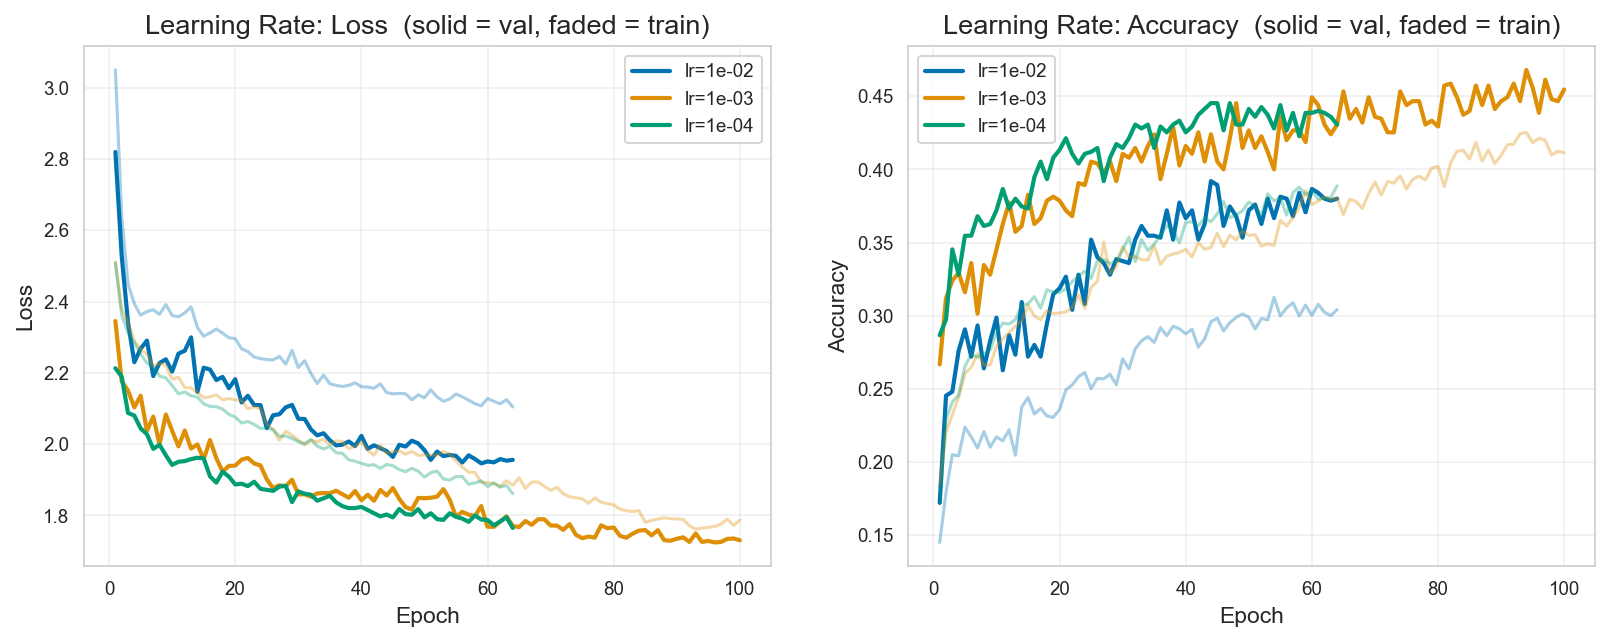

In [18]:
# Display the key results and learning curves
lr_summary = {
    name: {
        'best_val': f"{metrics['best_val_acc']:.2%}",
        'test_acc': f"{metrics['test_acc']:.2%}",
        'epochs': len(metrics['train_loss']),
    }
    for name, metrics in lr_results.items()
}

format_results_table(
    "Learning Rate Sensitivity - MLP C (Wide)",
    lr_summary,
    [
        ('LR', 'name'),
        ('Best Val', 'best_val'),
        ('Test Acc', 'test_acc'),
        ('Epochs', 'epochs'),
    ]
)

fig = plot_training_overlay(lr_results, 'Learning Rate')

save_fig(fig, 'lr_sensitivity')
plt.show()

## 6. Convolutional Neural Network (CNN)

Two architectures are compared using identical training settings to isolate the architectural effect:

1. **CNN-VGG**: VGGNet-inspired: stacked 3x3 convolutions, progressive channel doubling (64->128->256->512), max-pooling between blocks
2. **CNN-Res**: ResNet-inspired: strided convolutions for downsampling + residual (skip connection) blocks at each feature scale

Layer types used across both: `Conv2d`, `BatchNorm2d`, `ReLU`, `MaxPool2d`, `Dropout2d`, `AdaptiveAvgPool2d`, `Linear`, `BatchNorm1d`, `Dropout`.

In [ ]:
# Safely initialise the layers of the CNNs and build the CNN_VGG architecture

def init_conv_weights(model):
    """Initialize convolutional, batch-norm, and linear layers."""
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight)


class CNN_VGG(nn.Module):
    """
    VGG-inspired CNN.
    4 convolutional blocks with progressive channel doubling,
    followed by global average pooling and a fully-connected classifier.
    Input: 3 x 64 x 64 -> Output: num_classes
    """
    def __init__(self, num_classes):
        super().__init__()

        # Block 1: 64x64 -> 32x32
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        # Block 2: 32x32 -> 16x16
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        # Block 3: 16x16 -> 8x8
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.3)
        )
        # Block 4: 8x8 -> 4x4
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.3)
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )
        init_conv_weights(self)

    def forward(self, x):
        x = self.block1(x); x = self.block2(x)
        x = self.block3(x); x = self.block4(x)
        return self.classifier(x)

m = CNN_VGG(NUM_CLASSES)
print(f"CNN-VGG: {count_params(m):,} parameters")
print(m)

CNN-VGG: 5,563,343 parameters
CNN_VGG(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Con

In [ ]:
# Build the CNN_Res architecutre with reusable residual blocks

class ResBlock(nn.Module):
    """Two conv layers with a skip (identity) connection."""
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(ch)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + x)  # skip connection


class CNN_Res(nn.Module):
    """
    ResNet-inspired CNN with skip connections, built from scratch.
    Strided convolutions for downsampling; residual blocks refine features.
    Input: 3 x 64 x 64 -> Output: num_classes
    """
    def __init__(self, num_classes):
        """Build the ResNet-style CNN architecture."""
        super().__init__()
        # Stem: 64x64
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)

        # Stage 1: 64ch, 64x64 -> 32x32
        self.res1  = ResBlock(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout2d(0.2)

        # Stage 2: 128ch, 32x32 -> 16x16 (strided conv downsample)
        self.down2 = nn.Sequential(nn.Conv2d(64,  128, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.res2  = ResBlock(128)
        self.drop2 = nn.Dropout2d(0.2)

        # Stage 3: 256ch, 16x16 -> 8x8
        self.down3 = nn.Sequential(nn.Conv2d(128, 256, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.res3  = ResBlock(256)
        self.drop3 = nn.Dropout2d(0.3)

        # Stage 4: 512ch, 8x8 -> 4x4
        self.down4 = nn.Sequential(nn.Conv2d(256, 512, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True))
        self.res4  = ResBlock(512)
        self.drop4 = nn.Dropout2d(0.3)

        # Head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), 
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )
        init_conv_weights(self)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.drop1(self.pool1(self.res1(x)))
        x = self.drop2(self.res2(self.down2(x)))
        x = self.drop3(self.res3(self.down3(x)))
        x = self.drop4(self.res4(self.down4(x)))
        return self.head(x)

m = CNN_Res(NUM_CLASSES)
print(f"CNN-Res: {count_params(m):,} parameters")
print(m)

CNN-Res: 7,830,351 parameters
CNN_Res(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res1): ResBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout2d(p=0.2, inplace=False)
  (down2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (res2): ResBlock(
    (conv1): C

### 6.1 Training

Both architectures use identical settings: **Adam** (lr=1e-3, weight_decay=1e-4), **ReduceLROnPlateau** (patience=5, factor=0.5), early stopping patience=10. This isolates the effect of architecture from optimiser choice.

In [ ]:
# Run the training loop for CNN_VGG

model_vgg = CNN_VGG(NUM_CLASSES).to(device)
hist_vgg = run_experiment(
    'CNN-VGG',
    model_vgg,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader
)


Training CNN-VGG
  Epoch   1/100 | Train Loss: 2.5518 Acc: 0.1670 | Val Loss: 2.2707 Acc: 0.2733 | LR: 0.001000 | Time: 17s
  Epoch  10/100 | Train Loss: 1.9283 Acc: 0.3657 | Val Loss: 1.9423 Acc: 0.4000 | LR: 0.001000 | Time: 161s
  Epoch  20/100 | Train Loss: 1.6882 Acc: 0.4425 | Val Loss: 1.3661 Acc: 0.5587 | LR: 0.000500 | Time: 326s
  Epoch  30/100 | Train Loss: 2.2142 Acc: 0.2823 | Val Loss: 1.9663 Acc: 0.3547 | LR: 0.000250 | Time: 488s
  Epoch  40/100 | Train Loss: 2.0415 Acc: 0.3234 | Val Loss: 1.8315 Acc: 0.4013 | LR: 0.000063 | Time: 650s
  Early stopping at epoch 40
  Done in 649.8s | Best val acc: 55.87%
  Test accuracy: 52.13%


In [ ]:
# Run the training loop for CNN_Res

model_res = CNN_Res(NUM_CLASSES).to(device)
hist_res = run_experiment(
    'CNN-Res',
    model_res,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader
)


Training CNN-Res
  Epoch   1/100 | Train Loss: 2.7687 Acc: 0.1579 | Val Loss: 2.4933 Acc: 0.2987 | LR: 0.001000 | Time: 13s
  Epoch  10/100 | Train Loss: 1.8747 Acc: 0.3922 | Val Loss: 1.6928 Acc: 0.4520 | LR: 0.001000 | Time: 128s
  Epoch  20/100 | Train Loss: 1.5550 Acc: 0.4945 | Val Loss: 1.3658 Acc: 0.5627 | LR: 0.001000 | Time: 255s
  Epoch  30/100 | Train Loss: 1.3683 Acc: 0.5547 | Val Loss: 1.1594 Acc: 0.6013 | LR: 0.001000 | Time: 381s
  Epoch  40/100 | Train Loss: 1.2369 Acc: 0.5931 | Val Loss: 1.0701 Acc: 0.6573 | LR: 0.001000 | Time: 507s
  Epoch  50/100 | Train Loss: 0.9845 Acc: 0.6817 | Val Loss: 1.0252 Acc: 0.6720 | LR: 0.000500 | Time: 633s
  Epoch  60/100 | Train Loss: 0.8570 Acc: 0.7141 | Val Loss: 0.9727 Acc: 0.6947 | LR: 0.000500 | Time: 758s
  Epoch  70/100 | Train Loss: 0.6778 Acc: 0.7731 | Val Loss: 0.9348 Acc: 0.7187 | LR: 0.000250 | Time: 884s
  Epoch  80/100 | Train Loss: 0.5455 Acc: 0.8137 | Val Loss: 0.8955 Acc: 0.7307 | LR: 0.000063 | Time: 1008s
  Epoch  9

### 6.2 CNN Results

CNN Architecture Comparison
Config | Val Acc | Test Acc
---------------------------
CNN-VGG | 55.87% | 52.13%
CNN-Res | 74.80% | 71.33%

Best: CNN-Res


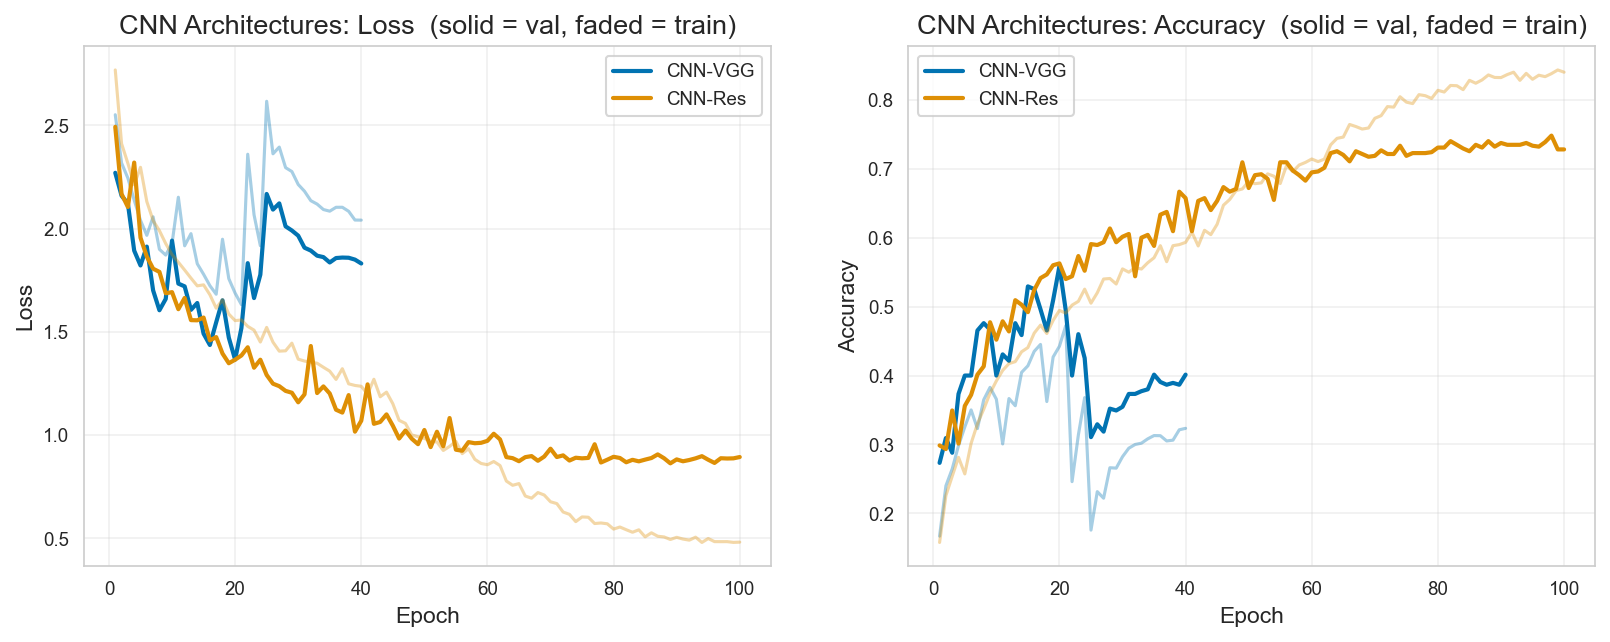

In [ ]:
# Compare the key results and display the learning curves of the two CNNs

cnn_results = {'CNN-VGG': hist_vgg, 'CNN-Res': hist_res}
cnn_models  = {'CNN-VGG': model_vgg, 'CNN-Res': model_res}

cnn_summary = {
    name: {
        'val_acc': f"{metrics['best_val_acc']:.2%}",
        'test_acc': f"{metrics['test_acc']:.2%}",
    }
    for name, metrics in cnn_results.items()
}

format_results_table(
    "CNN Architecture Comparison",
    cnn_summary,
    [
        ('Config', 'name'),
        ('Val Acc', 'val_acc'),
        ('Test Acc', 'test_acc'),
    ]
)

best_cnn_name, _ = select_best_result(cnn_results)
print(f"\nBest: {best_cnn_name}")

fig = plot_training_overlay(cnn_results, "CNN Architectures")
save_fig(fig, 'cnn_curves')
plt.show()

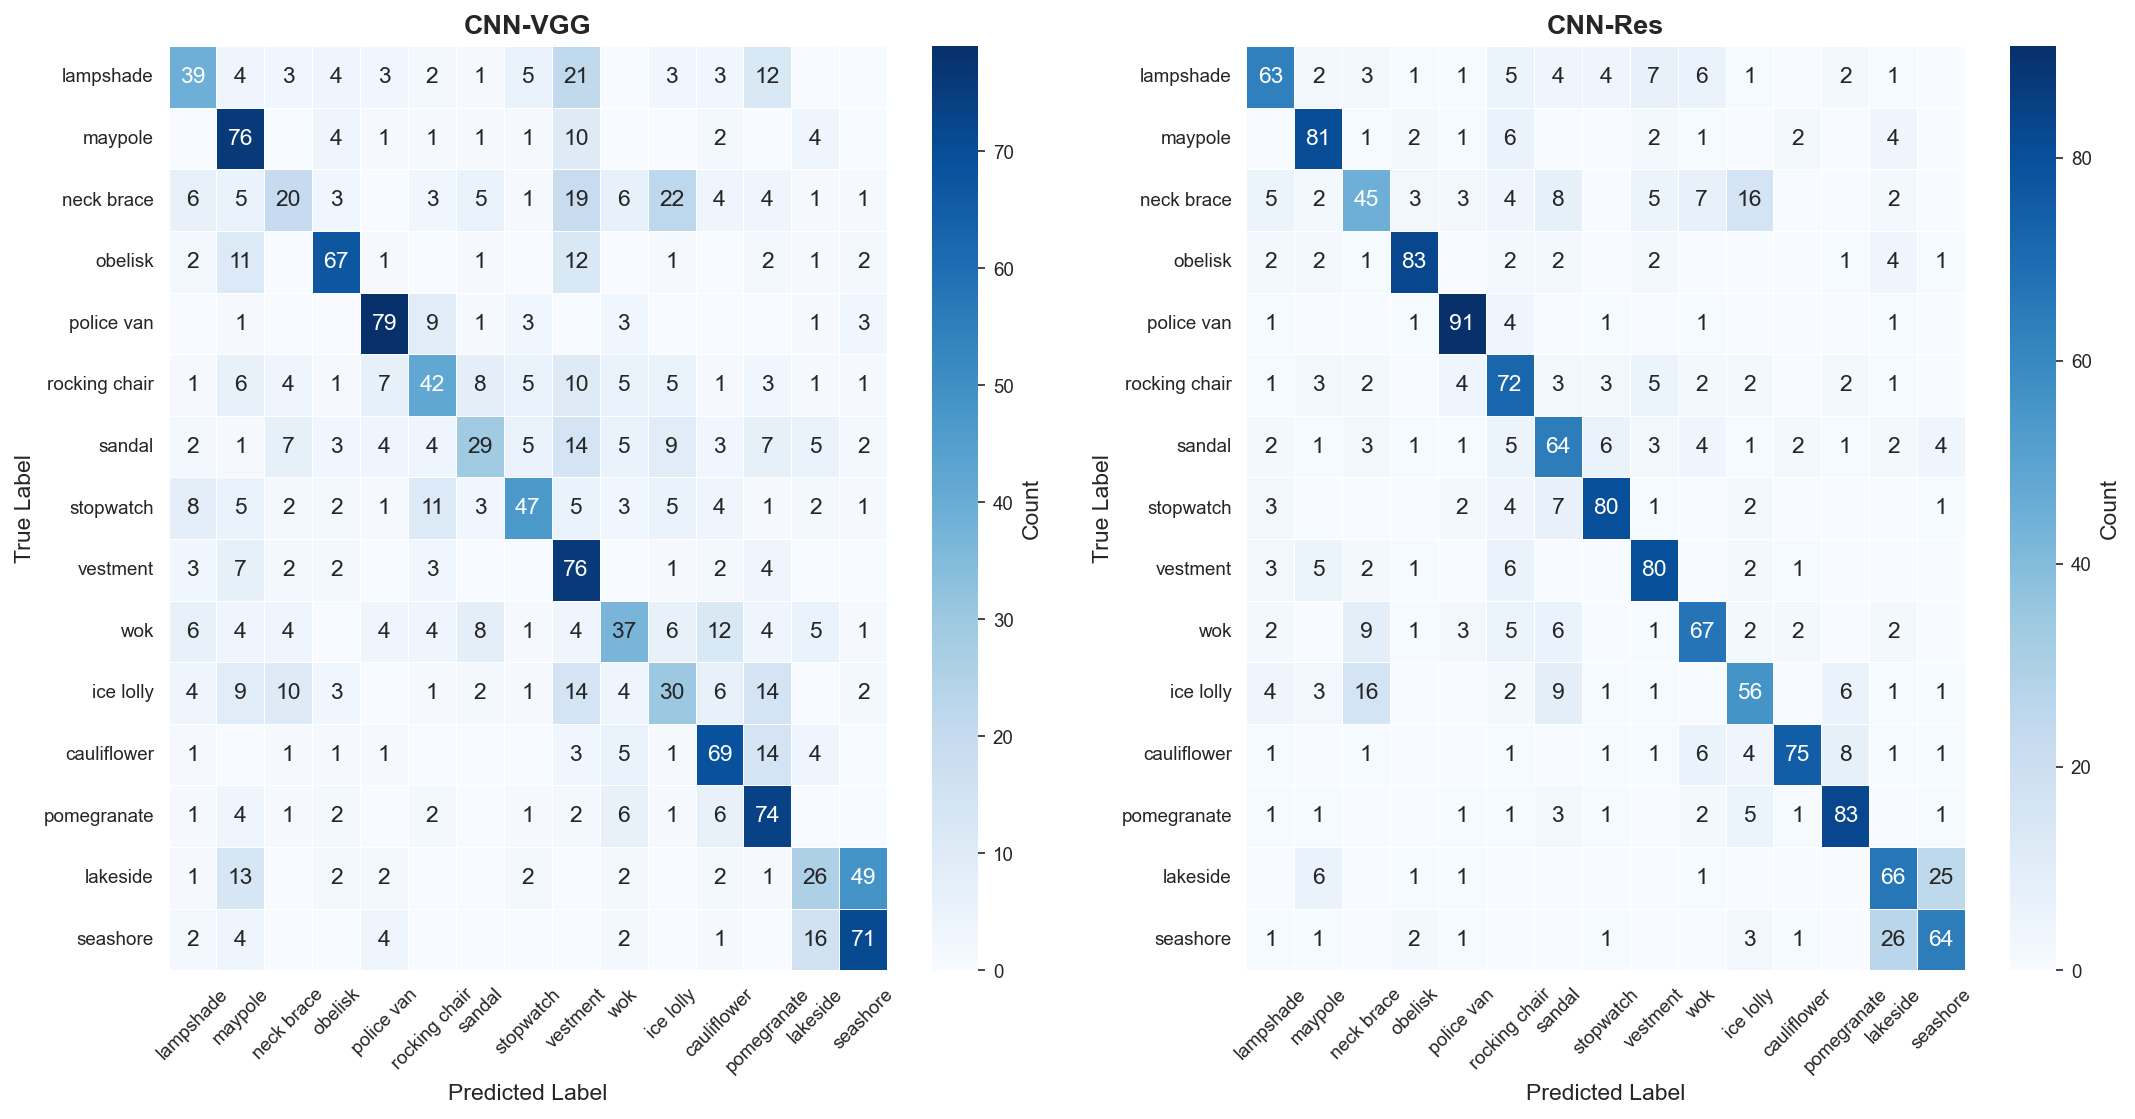


Classification Report: CNN-Res
               precision    recall  f1-score   support

    lampshade       0.71      0.63      0.67       100
      maypole       0.76      0.81      0.78       100
   neck brace       0.54      0.45      0.49       100
      obelisk       0.86      0.83      0.85       100
   police van       0.83      0.91      0.87       100
rocking chair       0.62      0.72      0.66       100
       sandal       0.60      0.64      0.62       100
    stopwatch       0.82      0.80      0.81       100
     vestment       0.74      0.80      0.77       100
          wok       0.69      0.67      0.68       100
    ice lolly       0.60      0.56      0.58       100
  cauliflower       0.89      0.75      0.82       100
  pomegranate       0.81      0.83      0.82       100
     lakeside       0.59      0.66      0.63       100
     seashore       0.65      0.64      0.65       100

     accuracy                           0.71      1500
    macro avg       0.71      0

In [ ]:
# Dislay the confusion matrices for the two CNNs

vgg_preds, vgg_labels_out = get_predictions(model_vgg, test_loader, device)
res_preds, res_labels_out = get_predictions(model_res, test_loader, device)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 8))
vgg_per_class_acc = plot_cm(vgg_labels_out, vgg_preds, short_names, "CNN-VGG", ax1)
res_per_class_acc = plot_cm(res_labels_out, res_preds, short_names, "CNN-Res", ax2)
save_fig(fig, 'cnn_cm_both')
plt.show()

# Select best for downstream comparison
if best_cnn_name == 'CNN-VGG':
    cnn_preds, cnn_labels_out, cnn_per_class_acc = vgg_preds, vgg_labels_out, vgg_per_class_acc
else:
    cnn_preds, cnn_labels_out, cnn_per_class_acc = res_preds, res_labels_out, res_per_class_acc

best_cnn_model = cnn_models[best_cnn_name]
print_classification_summary(cnn_labels_out, cnn_preds, short_names, best_cnn_name)

torch.save({
    'model_state_dict': best_cnn_model.state_dict(),
    'architecture': best_cnn_name,
    'test_acc': cnn_results[best_cnn_name]['test_acc'],
    'class_to_idx': class_to_idx
}, 'cnn_best.pth')
print("Saved cnn_best.pth")

## 7. Comparative Analysis

In [ ]:
# Reusable functions to visually compare key metrics of the models

def build_model_registry(entries):
    """Create a consistent registry for cross-model analysis in section 7."""
    registry = {}
    for entry in entries:
        key = entry['key']
        registry[key] = {
            'method': entry['method'],
            'test_acc': entry['test_acc'],
            'params': entry['params'],
            'preds': np.array(entry['preds']),
            'labels': np.array(entry['labels']),
            'history': entry.get('history'),
            'color': entry['color'],
            'bar_label': entry.get('bar_label', key),
        }
    return registry


def plot_comparison_bar(model_registry, title='Classification Accuracy by Approach'):
    """Bar chart comparing test accuracy across model approaches."""
    keys = list(model_registry.keys())
    accs = [model_registry[key]['test_acc'] for key in keys]
    colours = [model_registry[key]['color'] for key in keys]
    labels = [model_registry[key]['bar_label'] for key in keys]

    fig, ax = plt.subplots(figsize=(7.5, 5))
    sns.barplot(x=labels, y=accs, palette=colours, ax=ax)
    ax.set_ylim(0, min(1.0, max(accs) + 0.09))
    ax.set_title(title)
    ax.set_ylabel('Test Accuracy')
    return fig


def top_confusions(cm, names, k=5):
    """Return the top-k off-diagonal confusion pairs."""
    c = cm.copy().astype(float)
    np.fill_diagonal(c, 0)
    out = []
    for _ in range(k):
        i, j = np.unravel_index(c.argmax(), c.shape)
        out.append((names[i], names[j], int(c[i, j])))
        c[i, j] = 0
    return out


def print_top_confusions(model_registry, class_names, k=5, per_class_total=100):
    """Print top confusion pairs for each model in the registry."""
    print(f"Top-{k} Confused Class Pairs  (true -> predicted, out of {per_class_total})")
    print("=" * 65)
    for name, info in model_registry.items():
        cm = confusion_matrix(info['labels'], info['preds'])
        pairs = top_confusions(cm, class_names, k=k)
        print(f"\n{name}:")
        for true, pred, n in pairs:
            print(f"  {true:<18s} -> {pred:<18s}  ({n}/{per_class_total})")


def train_test_gap_table(model_registry):
    """Print final-train vs test gaps for models that have training history."""
    gap_results = {}
    for name, info in model_registry.items():
        history = info.get('history')
        if history is None:
            continue
        train_acc = history['train_acc'][-1]
        test_acc = info['test_acc']
        gap = train_acc - test_acc
        gap_results[name] = {
            'train': f"{train_acc:.4f}",
            'test': f"{test_acc:.4f}",
            'gap': f"{gap:+.4f}",
        }

    format_results_table(
        "Train vs Test Accuracy Gap",
        gap_results,
        [
            ('Model', 'name'),
            ('Final Train', 'train'),
            ('Test Acc', 'test'),
            ('Gap', 'gap'),
        ]
    )


def plot_lr_schedules(named_histories):
    """Plot learning-rate schedules for one or more histories."""
    items = list(named_histories.items())
    fig, axes = plt.subplots(1, len(items), figsize=(6.5 * len(items), 4))
    if len(items) == 1:
        axes = [axes]

    for ax, (name, hist) in zip(axes, items):
        ep = range(1, len(hist['lr']) + 1)
        ax.semilogy(ep, hist['lr'], color=CB[1], lw=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Learning Rate (log scale)')
        ax.set_title(f'{name}: LR Schedule')
    return fig

         Approach          Method Test Accuracy    Parameters
Hand-Crafted (A1) SIFT + FV + SVM        55.87% ~16K (FV dim)
   MLP (C (Wide))             MLP        45.20%    27,287,567
    CNN (CNN-Res)         CNN-Res        71.33%     7,830,351


C:\Users\cbrow\AppData\Local\Temp\ipykernel_13480\3985754084.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=accs, palette=colours, ax=ax)


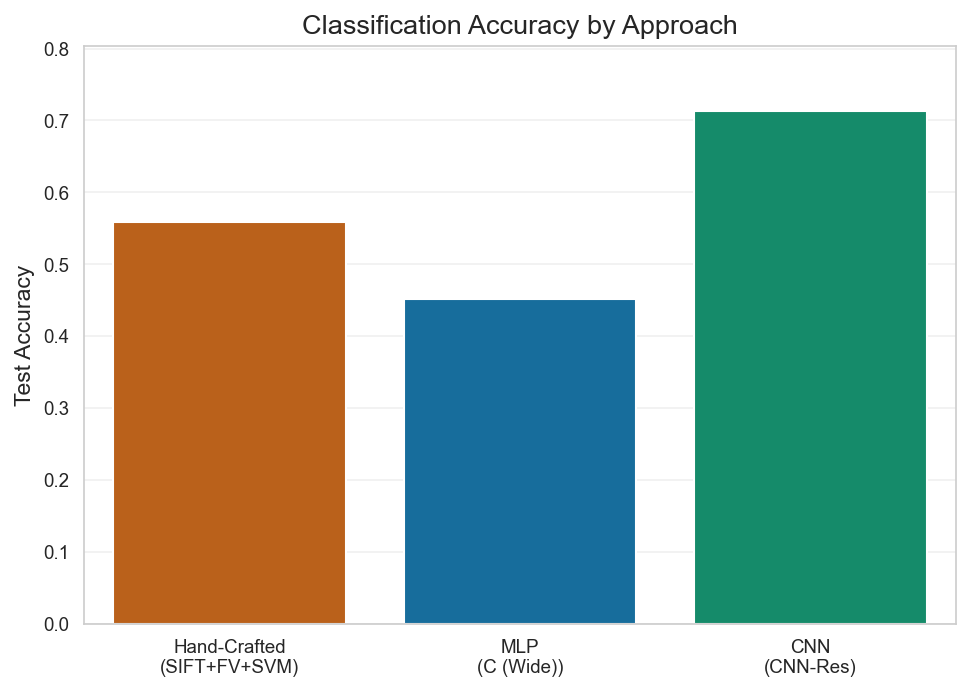

In [ ]:
# Build a registry of the best model for each approach - hand-crafted, MLP, CNN - and display the results

model_registry = build_model_registry([
    {
        'key': 'Hand-Crafted (A1)',
        'method': 'SIFT + FV + SVM',
        'test_acc': a1_accuracy,
        'params': '~16K (FV dim)',
        'preds': a1_preds,
        'labels': a1_test_labels,
        'history': None,
        'color': C_A1,
        'bar_label': 'Hand-Crafted\n(SIFT+FV+SVM)',
    },
    {
        'key': f'MLP ({best_nn_name})',
        'method': 'MLP',
        'test_acc': nn_results[best_nn_name]['test_acc'],
        'params': f"{count_params(best_nn_model):,}",
        'preds': nn_preds,
        'labels': nn_labels,
        'history': nn_results[best_nn_name],
        'color': C_NN,
        'bar_label': f'MLP\n({best_nn_name})',
    },
    {
        'key': f'CNN ({best_cnn_name})',
        'method': best_cnn_name,
        'test_acc': cnn_results[best_cnn_name]['test_acc'],
        'params': f"{count_params(best_cnn_model):,}",
        'preds': cnn_preds,
        'labels': cnn_labels_out,
        'history': cnn_results[best_cnn_name],
        'color': C_CNN,
        'bar_label': f'CNN\n({best_cnn_name})',
    },
])

comparison_df = pd.DataFrame([
    {
        'Approach': name,
        'Method': info['method'],
        'Test Accuracy': f"{info['test_acc']:.2%}",
        'Parameters': info['params'],
    }
    for name, info in model_registry.items()
])
print(comparison_df.to_string(index=False))

fig = plot_comparison_bar(model_registry)
save_fig(fig, 'comparison_bar')
plt.show()

### 7.1 Error Analysis

In [27]:
print_top_confusions(model_registry, short_names, k=5, per_class_total=100)

Top-5 Confused Class Pairs  (true -> predicted, out of 100)

Hand-Crafted (A1):
  lakeside           -> seashore            (40/100)
  wok                -> cauliflower         (17/100)
  neck brace         -> ice lolly           (16/100)
  lakeside           -> maypole             (16/100)
  ice lolly          -> cauliflower         (15/100)

MLP (C (Wide)):
  lakeside           -> seashore            (29/100)
  seashore           -> lakeside            (17/100)
  ice lolly          -> neck brace          (16/100)
  neck brace         -> ice lolly           (15/100)
  stopwatch          -> sandal              (12/100)

CNN (CNN-Res):
  seashore           -> lakeside            (26/100)
  lakeside           -> seashore            (25/100)
  neck brace         -> ice lolly           (16/100)
  ice lolly          -> neck brace          (16/100)
  wok                -> neck brace          (9/100)


### 7.2 Data Augmentation Ablation

In [ ]:
# Train CNN-Res without any augmentation (uses eval_transform) to measure its contribution
model_res_noaug = CNN_Res(NUM_CLASSES).to(device)

train_dataset_noaug = TinyImageNetSubset(train_files, eval_transform)
train_loader_noaug = DataLoader(train_dataset_noaug, batch_size=BATCH_SIZE,
                                 shuffle=True, num_workers=0, pin_memory=True)

hist_noaug = run_experiment(
    'CNN-Res WITHOUT data augmentation',
    model_res_noaug,
    train_loader=train_loader_noaug,
    val_loader=val_loader,
    test_loader=test_loader,
    scheduler_patience=7,
)
acc_noaug = hist_noaug['test_acc']


Training CNN-Res WITHOUT data augmentation
  Epoch   1/100 | Train Loss: 2.6190 Acc: 0.1971 | Val Loss: 2.1796 Acc: 0.3133 | LR: 0.001000 | Time: 10s
  Epoch  10/100 | Train Loss: 1.4762 Acc: 0.5211 | Val Loss: 1.4246 Acc: 0.5413 | LR: 0.001000 | Time: 95s
  Epoch  20/100 | Train Loss: 1.0227 Acc: 0.6657 | Val Loss: 1.2728 Acc: 0.5947 | LR: 0.001000 | Time: 189s
  Epoch  30/100 | Train Loss: 0.2591 Acc: 0.9179 | Val Loss: 1.1610 Acc: 0.6773 | LR: 0.000250 | Time: 283s
  Epoch  40/100 | Train Loss: 0.0938 Acc: 0.9754 | Val Loss: 1.2832 Acc: 0.6800 | LR: 0.000125 | Time: 378s
  Epoch  50/100 | Train Loss: 0.0477 Acc: 0.9901 | Val Loss: 1.3647 Acc: 0.6733 | LR: 0.000063 | Time: 474s
  Epoch  60/100 | Train Loss: 0.0344 Acc: 0.9939 | Val Loss: 1.3441 Acc: 0.6707 | LR: 0.000031 | Time: 568s
  Early stopping at epoch 61
  Done in 577.4s | Best val acc: 69.47%
  Test accuracy: 64.07%


CNN-Res Augmentation Ablation
Metric | With Aug | No Aug | Delta
----------------------------------
Test accuracy | 71.33% | 64.07% | 7.27%
Final train accuracy | 84.00% | 99.50% | -15.50%
Train-test gap | 12.67% | 35.44% | -22.77%


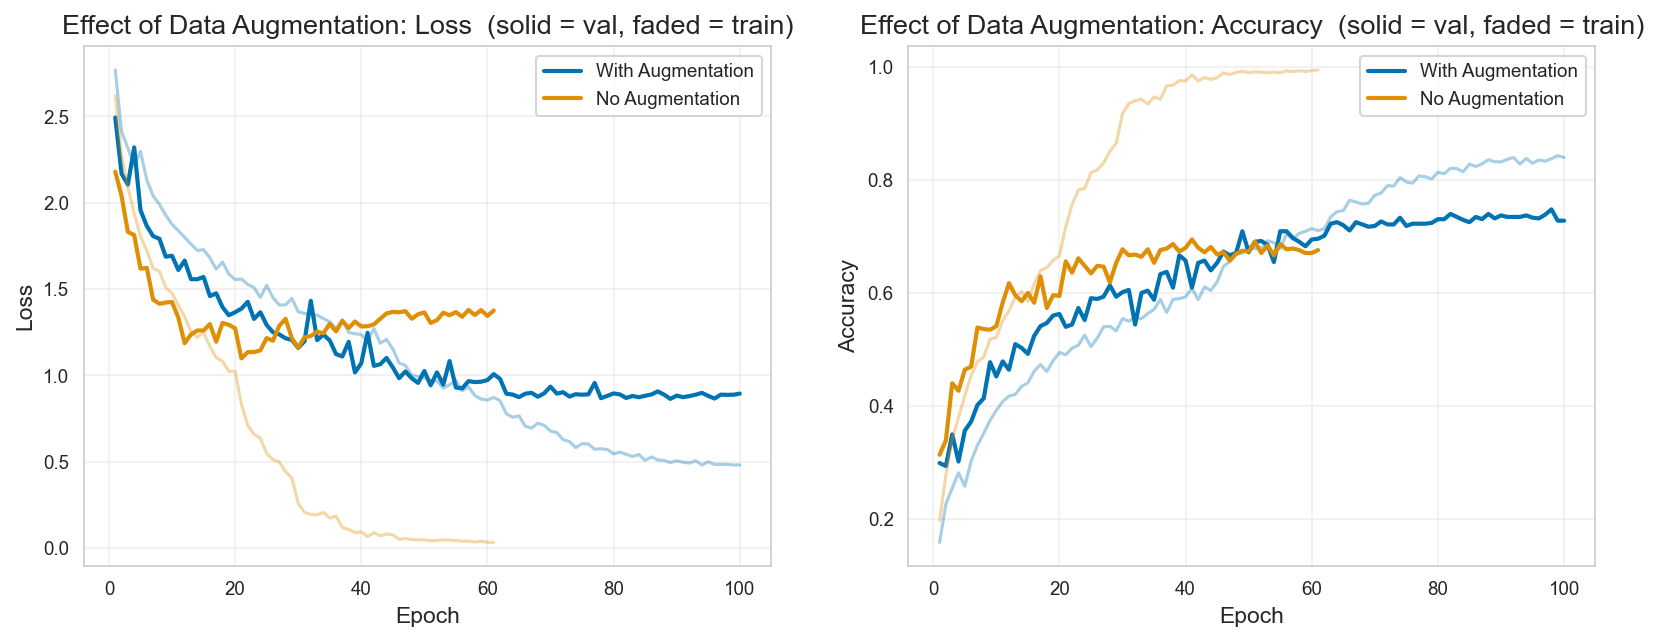

In [29]:
# Compare augmented vs non-augmented CNN-Res
aug_acc = cnn_results['CNN-Res']['test_acc']
noaug_acc = acc_noaug
aug_train_final = cnn_results['CNN-Res']['train_acc'][-1]
noaug_train_final = hist_noaug['train_acc'][-1]

ablation_results = {
    'Test accuracy': {
        'with_aug': aug_acc,
        'no_aug': noaug_acc,
    },
    'Final train accuracy': {
        'with_aug': aug_train_final,
        'no_aug': noaug_train_final,
    },
    'Train-test gap': {
        'with_aug': aug_train_final - aug_acc,
        'no_aug': noaug_train_final - noaug_acc,
    },
}
ablation_summary = {
    metric: {
        'with_aug': f"{values['with_aug']:.2%}",
        'no_aug': f"{values['no_aug']:.2%}",
        'delta': f"{values['with_aug'] - values['no_aug']:.2%}",
    }
    for metric, values in ablation_results.items()
}

format_results_table(
    "CNN-Res Augmentation Ablation",
    ablation_summary,
    [
        ('Metric', 'name'),
        ('With Aug', 'with_aug'),
        ('No Aug', 'no_aug'),
        ('Delta', 'delta'),
    ]
)

aug_hist = {
    'With Augmentation': cnn_results['CNN-Res'],
    'No Augmentation': hist_noaug,
}
fig = plot_training_overlay(aug_hist, "Effect of Data Augmentation")
save_fig(fig, 'augmentation_ablation')
plt.show()

## 8. Model Verification

Load the saved models and verify they reproduce the reported test accuracies.

In [ ]:
# Verify saved models reproduce reported accuracy

nn_ck = torch.load('nn_best.pth', map_location=device, weights_only=True)
nn_v = MLP(INPUT_DIM, nn_configs[best_nn_name]['hidden_sizes'],
           NUM_CLASSES, nn_configs[best_nn_name]['dropout_rates']).to(device)
nn_v.load_state_dict(nn_ck['model_state_dict'])
_, acc = run_epoch(nn_v, test_loader, nn.CrossEntropyLoss(), device, optimizer=None)
reported_nn = nn_results[best_nn_name]['test_acc']
print(f"NN  saved model: {acc}  (reported: {reported_nn})")

cnn_ck = torch.load('cnn_best.pth', map_location=device, weights_only=True)
cnn_v = (CNN_VGG if 'VGG' in best_cnn_name else CNN_Res)(NUM_CLASSES).to(device)
cnn_v.load_state_dict(cnn_ck['model_state_dict'])
_, acc = run_epoch(cnn_v, test_loader, nn.CrossEntropyLoss(), device, optimizer=None)
reported_cnn = cnn_results[best_cnn_name]['test_acc']
print(f"CNN saved model: {acc}  (reported: {reported_cnn})")

Verifying saved models reproduce reported accuracy...
NN  saved model: 0.452  (reported: 0.452)
CNN saved model: 0.7133333333333334  (reported: 0.7133333333333334)

Verification complete.


## AI Declaration

Claude was used to produce an initial literature review to frame my own analysis. Claude was used to write the conclusion based on the report - all writing until that point is my own. Cursor tab was used for code autocompletion and used to refactor common patterns into modular functions.